# CatBoost: режимы и устойчивость
Проверяю схему бустинга, стратегии таргета, параметры листьев и раннюю остановку, устойчивость во времени и оценку неопределённости.

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

datapath = "/kaggle/input/datasets/vikakolganova/crmses/sessions_crm.parquet"
seed = 42
maxrows = 90000
np.random.seed(seed)

data = pd.read_parquet(datapath)
for c in ["start", "end", "install_datetime", "prev_session_end", "session_date"]:
    if c in data.columns:
        data[c] = pd.to_datetime(data[c], errors="coerce")
print(data.shape)

(3071996, 85)


In [2]:
targets = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d"]
labels = {"target_next_session_length_sec": "next_session", "future_sessions_mean_playtime_7d": "crm_7d"}

from types import SimpleNamespace

blacklist = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d", "target_log1p",
             "appmetrica_device_id", "installation_id", "session_id",
             "start", "end", "duration_hms", "session_date", "install_datetime", "prev_session_end"]

def prepare(data, target):
    d = data.sort_values("start").reset_index(drop=True)
    if len(d) > maxrows:
        d = d.tail(maxrows).reset_index(drop=True)
    feats = [c for c in d.columns if c not in blacklist and not c.startswith("target") and not c.startswith("future_")]
    catcols = [c for c in feats if not pd.api.types.is_numeric_dtype(d[c])]
    for c in feats:
        if c in catcols:
            d[c] = d[c].astype(str).fillna("unknown")
        else:
            d[c] = d[c].fillna(d[c].median())
    n = len(d)
    i = int(n * 0.70)
    j = int(n * 0.85)
    x = d[feats]
    y = d[target].values.astype(float)
    pack = SimpleNamespace(xtrain=x.iloc[:i].reset_index(drop=True),
                           xval=x.iloc[i:j].reset_index(drop=True),
                           xtest=x.iloc[j:].reset_index(drop=True),
                           ytrain=y[:i], yval=y[i:j], ytest=y[j:],
                           catcols=catcols, target=target)
    for c in catcols:
        pack.xtrain[c] = pack.xtrain[c].astype(str)
        pack.xval[c] = pack.xval[c].astype(str)
        pack.xtest[c] = pack.xtest[c].astype(str)
    return pack

packs = {t: prepare(data, t) for t in targets}
print(packs[targets[0]].xtrain.shape, packs[targets[0]].catcols)

(62999, 73) ['publisher_name', 'tracker_name', 'attributed_touch_type', 'country_iso_code', 'device_type', 'app_version_name', 'connection_type', 'traffic_source', 'install_country', 'install_device_type', 'install_app_version_name', 'install_connection_type', 'most_common_event_name', 'most_common_connection_type']


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prodmae(yt, yp, cap=1200, tail=0.2, over=2.0, under=1.0):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    a = np.minimum(yt, cap)
    b = np.minimum(yp, cap)
    err = b - a
    w = np.where(yt > cap, tail, 1.0) * np.where(err > 0, over, under)
    return np.sum(w * np.abs(err)) / np.sum(w)

def engmae(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    ae = np.abs(yt - yp)
    w = np.select([yt <= 300, (yt > 300) & (yt <= 1200), yt > 1200], [1.0, 0.67, 0.05])
    return np.sum(w * ae) / np.sum(w)

def segmae(yt, yp, lo, hi):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    m = (yt > lo) & (yt <= hi)
    if m.any():
        return float(np.mean(np.abs(yt[m] - yp[m])))
    return np.nan

def score(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.clip(np.asarray(yp, float), 0, None)
    ae = np.abs(yt - yp)
    return {"mae": mean_absolute_error(yt, yp),
            "rmse": mean_squared_error(yt, yp) ** 0.5,
            "medae": float(np.median(ae)),
            "r2": r2_score(yt, yp),
            "p70_abs_error": float(np.percentile(ae, 70)),
            "p90_abs_error": float(np.percentile(ae, 90)),
            "product_mae": prodmae(yt, yp),
            "engagement_risk_mae": engmae(yt, yp),
            "small_mae": segmae(yt, yp, -1, 300),
            "normal_mae": segmae(yt, yp, 300, 1200),
            "long_mae": segmae(yt, yp, 1200, 1e18)}

rows = []
preds = {}

def record(target, family, name, mode, loss, yval, valpred, ytest=None, testpred=None,
           params="", btmean=np.nan, btstd=np.nan, fitsec=0.0):
    row = {"target": target, "target_label": labels.get(target, target), "model_family": family,
           "model_name": name, "objective_tag": loss, "target_mode": mode, "loss_function": loss,
           "feature_set": "all", "params": params, "fit_sec": round(fitsec, 1), "status": "ok"}
    mv = score(yval, valpred)
    for k, v in mv.items():
        row["val_" + k] = v
    if testpred is not None:
        for k, v in score(ytest, testpred).items():
            row["test_" + k] = v
        preds[(target, name)] = (np.asarray(ytest, float), np.clip(np.asarray(testpred, float), 0, None))
    row["backtest_mae_mean"] = btmean
    row["backtest_mae_std"] = btstd
    rows.append(row)
    msg = labels.get(target, target) + "  " + name + "  val_mae=" + str(round(mv["mae"], 1)) + "  r2=" + str(round(mv["r2"], 2))
    if testpred is not None:
        msg += "  test_mae=" + str(round(row["test_mae"], 1))
    print(msg)

In [4]:
def makescale(ytrain, mode):
    cap = np.percentile(np.asarray(ytrain, float), 99.5)
    if mode == "raw":
        return (lambda s: np.asarray(s, float)), (lambda s: np.asarray(s, float))
    if mode == "p995":
        return (lambda s: np.clip(np.asarray(s, float), 0, cap)), (lambda s: np.asarray(s, float))
    return (lambda s: np.log1p(np.clip(np.asarray(s, float), 0, cap))), (lambda s: np.expm1(np.asarray(s, float)))

In [5]:
from catboost import CatBoostRegressor, Pool

tasktype = "GPU"
devices = "0"

def makecat(**params):
    params["task_type"] = tasktype
    if tasktype == "GPU":
        params["devices"] = devices
    return CatBoostRegressor(**params)

def runcat(pack, loss="MAE", mode="log1p_p995", iterations=600, depth=6, lr=0.05,
           boosting="Plain", hastime=True, leafiters=None, leafmethod=None, odwait=80, rs=seed):
    fwd, inv = makescale(pack.ytrain, mode)
    pooltr = Pool(pack.xtrain, fwd(pack.ytrain), cat_features=pack.catcols)
    poolvl = Pool(pack.xval, fwd(pack.yval), cat_features=pack.catcols)
    par = dict(iterations=iterations, depth=depth, learning_rate=lr, loss_function=loss,
               boosting_type=boosting, has_time=hastime, random_seed=rs,
               od_type="Iter", od_wait=odwait, verbose=0)
    if leafiters is not None:
        par["leaf_estimation_iterations"] = leafiters
    if leafmethod is not None:
        par["leaf_estimation_method"] = leafmethod
    t0 = time.time()
    try:
        m = makecat(**par)
        m.fit(pooltr, eval_set=poolvl, use_best_model=True)
    except Exception:
        m = CatBoostRegressor(**par)
        m.fit(pooltr, eval_set=poolvl, use_best_model=True)
    pv = inv(m.predict(pack.xval))
    pt = inv(m.predict(pack.xtest))
    return pv, pt, time.time() - t0, m

## Plain vs Ordered
Ordered boosting уменьшает prediction shift, но медленнее.

In [6]:
plainmodels = {}
for t in targets:
    pack = packs[t]
    for bt in ["Plain", "Ordered"]:
        pv, pt, fs, m = runcat(pack, boosting=bt, iterations=500)
        if bt == "Plain":
            plainmodels[t] = m
        record(t, "catboost", "cat_" + bt.lower() + "_hastime", "log1p_p995", "MAE",
               pack.yval, pv, pack.ytest, pt, params="boosting=" + bt, fitsec=fs)

Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_plain_hastime  val_mae=557.8  r2=0.03  test_mae=600.8


Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_ordered_hastime  val_mae=557.6  r2=0.02  test_mae=600.5


Default metric period is 5 because MAE is/are not implemented for GPU


crm_7d  cat_plain_hastime  val_mae=264.5  r2=0.3  test_mae=262.7


Default metric period is 5 because MAE is/are not implemented for GPU


crm_7d  cat_ordered_hastime  val_mae=266.2  r2=0.3  test_mae=261.8


## Стратегии таргета
capped обычно лучше по обычному MAE, квантильные лоссы осторожнее на коротких сессиях.

In [7]:
for t in targets:
    pack = packs[t]
    pv, pt, fs, m = runcat(pack, mode="p995", iterations=500)
    record(t, "catboost", "cat_capped_target", "p995", "MAE", pack.yval, pv, pack.ytest, pt, fitsec=fs)
    for a in [0.40, 0.35]:
        pv, pt, fs, m = runcat(pack, loss="Quantile:alpha=" + str(a), iterations=500)
        record(t, "catboost", "cat_quantile_" + str(int(a * 100)), "log1p_p995",
               "Quantile:alpha=" + str(a), pack.yval, pv, pack.ytest, pt, fitsec=fs)

Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_capped_target  val_mae=557.6  r2=0.03  test_mae=600.6
next_session  cat_quantile_40  val_mae=566.0  r2=-0.02  test_mae=611.9
next_session  cat_quantile_35  val_mae=576.4  r2=-0.04  test_mae=622.9


Default metric period is 5 because MAE is/are not implemented for GPU


crm_7d  cat_capped_target  val_mae=265.3  r2=0.31  test_mae=263.7
crm_7d  cat_quantile_40  val_mae=268.5  r2=0.24  test_mae=269.0
crm_7d  cat_quantile_35  val_mae=275.6  r2=0.2  test_mae=275.3


## Leaf estimation и od_wait
Локальная проверка вокруг лучшей конфигурации, только next_session.

In [8]:
pack = packs[targets[0]]
t = pack.target
for li, lm in [(1, "Gradient"), (3, "Gradient"), (5, "Exact")]:
    pv, pt, fs, m = runcat(pack, iterations=400, leafiters=li, leafmethod=lm)
    record(t, "catboost", "cat_leaf_" + lm.lower() + "_" + str(li), "log1p_p995", "MAE",
           pack.yval, pv, pack.ytest, pt, params="leaf_iters=" + str(li) + "," + lm, fitsec=fs)
for ow in [50, 150]:
    pv, pt, fs, m = runcat(pack, iterations=600, odwait=ow)
    record(t, "catboost", "cat_odwait_" + str(ow), "log1p_p995", "MAE",
           pack.yval, pv, pack.ytest, pt, params="od_wait=" + str(ow), fitsec=fs)

Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_leaf_gradient_1  val_mae=557.4  r2=0.02  test_mae=600.5


Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_leaf_gradient_3  val_mae=557.1  r2=0.02  test_mae=600.5


Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_leaf_exact_5  val_mae=557.8  r2=0.03  test_mae=600.8


Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_odwait_50  val_mae=557.8  r2=0.03  test_mae=600.8


Default metric period is 5 because MAE is/are not implemented for GPU


next_session  cat_odwait_150  val_mae=557.8  r2=0.03  test_mae=600.8


## Rolling backtest
Три окна по времени: train первые 50, 60 и 70 процентов, validation следующие 15.

In [9]:
def backtest(pack, loss="MAE", mode="log1p_p995"):
    x = pd.concat([pack.xtrain, pack.xval, pack.xtest], ignore_index=True)
    y = np.concatenate([pack.ytrain, pack.yval, pack.ytest])
    maes = []
    for a, b, c in [(0.0, 0.50, 0.65), (0.0, 0.60, 0.75), (0.0, 0.70, 0.85)]:
        n = len(x)
        tr = slice(int(n * a), int(n * b))
        vl = slice(int(n * b), int(n * c))
        fwd, inv = makescale(y[tr], mode)
        m = makecat(iterations=400, depth=6, learning_rate=0.05, loss_function=loss,
                    random_seed=seed, verbose=0)
        m.fit(Pool(x.iloc[tr], fwd(y[tr]), cat_features=pack.catcols))
        pred = inv(m.predict(x.iloc[vl]))
        maes.append(score(y[vl], pred)["mae"])
    return float(np.mean(maes)), float(np.std(maes))

btres = {}
for t in targets:
    bm, bs = backtest(packs[t])
    btres[t] = (bm, bs)
    print(labels[t], "mean", round(bm, 1), "std", round(bs, 1), "balanced", round(bm + 0.2 * bs, 1))
    cand = [r for r in rows if r["target"] == t and r["model_family"] == "catboost"]
    best = min(cand, key=lambda r: r["val_mae"])
    best["backtest_mae_mean"] = bm
    best["backtest_mae_std"] = bs

Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


next_session mean 550.5 std 7.7 balanced 552.0


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


crm_7d mean 258.0 std 5.6 balanced 259.1


## Неопределённость
Смотрю связана ли оценка неопределённости с реальной ошибкой.

In [10]:
pack = packs[targets[0]]
t = pack.target
fwd, inv = makescale(pack.ytrain, "log1p_p995")
pooltr = Pool(pack.xtrain, fwd(pack.ytrain), cat_features=pack.catcols)
mu = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05,
                       loss_function="RMSEWithUncertainty", posterior_sampling=True,
                       random_seed=seed, task_type="CPU", verbose=0)
mu.fit(pooltr)
ve = np.asarray(mu.virtual_ensembles_predict(pack.xval, prediction_type="TotalUncertainty", virtual_ensembles_count=10))
pred = inv(ve[:, 0])
unc = ve[:, 1] + ve[:, 2]
record(t, "catboost", "cat_uncertainty", "log1p_p995", "RMSEWithUncertainty", pack.yval, pred)
abserr = np.abs(np.asarray(pack.yval, float) - np.clip(pred, 0, None))
uncstd = np.sqrt(np.clip(unc, 0, None))
corr = np.corrcoef(uncstd, abserr)[0, 1]
print("corr =", round(corr, 3))

next_session  cat_uncertainty  val_mae=563.8  r2=-0.02
corr = 0.084


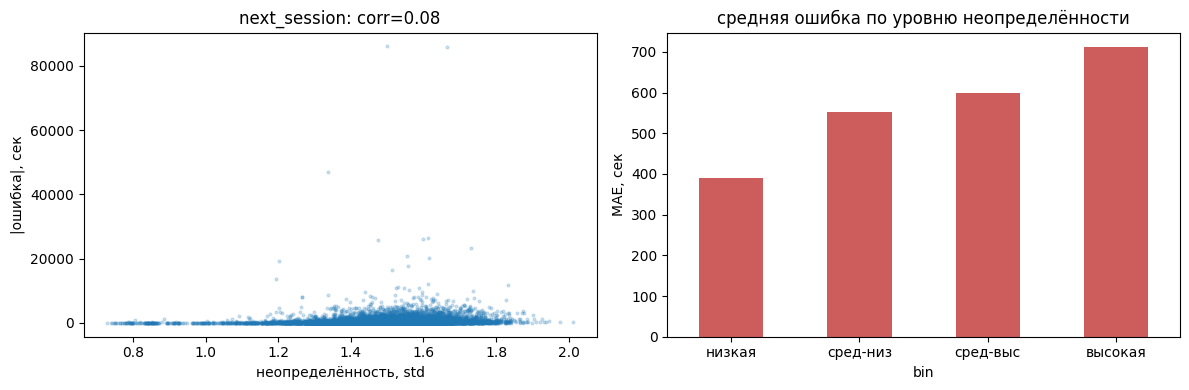

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(uncstd, abserr, s=4, alpha=0.2)
ax[0].set_xlabel("неопределённость, std")
ax[0].set_ylabel("|ошибка|, сек")
ax[0].set_title("next_session: corr=" + str(round(corr, 2)))
q = pd.qcut(unc, 4, labels=["низкая", "сред-низ", "сред-выс", "высокая"])
bybin = pd.DataFrame({"bin": q, "abserr": abserr}).groupby("bin")["abserr"].mean()
bybin.plot.bar(ax=ax[1], color="indianred", rot=0)
ax[1].set_title("средняя ошибка по уровню неопределённости")
ax[1].set_ylabel("MAE, сек")
plt.tight_layout()
plt.show()

## Важность признаков

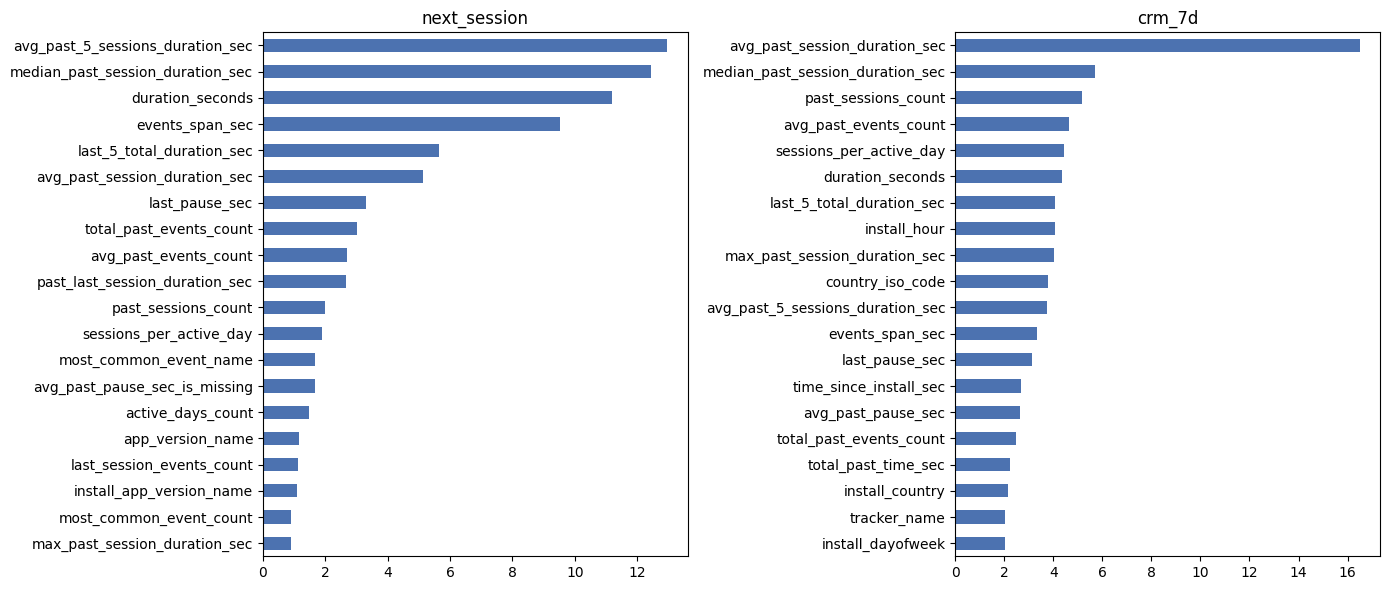

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, t in zip(axes, targets):
    imp = pd.Series(plainmodels[t].get_feature_importance(), index=packs[t].xtrain.columns)
    imp.sort_values().tail(20).plot.barh(ax=ax, color="#4c72b0")
    ax.set_title(labels[t])
plt.tight_layout()
plt.show()

## Таблица результатов

In [13]:
res = pd.DataFrame(rows)
cols = ["model_name", "target_mode", "loss_function", "val_mae", "val_r2",
        "val_product_mae", "val_engagement_risk_mae", "test_mae", "fit_sec"]
for t in targets:
    print(labels[t])
    display(res[res["target"] == t].sort_values("val_mae")[cols].round(2))

next_session


,model_name,target_mode,loss_function,val_mae,val_r2,val_product_mae,val_engagement_risk_mae,test_mae,fit_sec
11,cat_leaf_gradient_3,log1p_p995,MAE,557.13,0.02,263.24,275.96,600.54,7.2
10,cat_leaf_gradient_1,log1p_p995,MAE,557.36,0.02,260.01,272.46,600.54,7.7
1,cat_ordered_hastime,log1p_p995,MAE,557.56,0.02,261.79,274.52,600.53,15.5
4,cat_capped_target,p995,MAE,557.56,0.03,265.26,277.43,600.59,5.8
12,cat_leaf_exact_5,log1p_p995,MAE,557.85,0.03,266.84,279.21,600.83,6.5
0,cat_plain_hastime,log1p_p995,MAE,557.85,0.03,266.84,279.21,600.83,7.7
14,cat_odwait_150,log1p_p995,MAE,557.85,0.03,266.84,279.21,600.83,7.8
13,cat_odwait_50,log1p_p995,MAE,557.85,0.03,266.84,279.21,600.83,6.0
15,cat_uncertainty,log1p_p995,RMSEWithUncertainty,563.82,-0.02,231.84,244.53,NaN,0.0
5,cat_quantile_40,log1p_p995,Quantile:alpha=0.4,566.01,-0.02,230.78,241.96,611.92,4.6


crm_7d


,model_name,target_mode,loss_function,val_mae,val_r2,val_product_mae,val_engagement_risk_mae,test_mae,fit_sec
2,cat_plain_hastime,log1p_p995,MAE,264.55,0.30,181.35,186.87,262.66,9.8
7,cat_capped_target,p995,MAE,265.33,0.31,184.26,189.76,263.67,9.8
3,cat_ordered_hastime,log1p_p995,MAE,266.18,0.30,182.97,188.50,261.83,15.9
8,cat_quantile_40,log1p_p995,Quantile:alpha=0.4,268.55,0.24,169.22,176.33,268.96,10.1
9,cat_quantile_35,log1p_p995,Quantile:alpha=0.35,275.61,0.20,169.59,176.92,275.25,9.8


## Время обучения Plain и Ordered

In [14]:
for t in targets:
    sub = res[res["target"] == t].set_index("model_name")
    p = sub.loc["cat_plain_hastime", "fit_sec"]
    o = sub.loc["cat_ordered_hastime", "fit_sec"]
    print(labels[t], " plain", p, "сек  ordered", o, "сек  дольше в", round(o / p, 1), "раза")

next_session  plain 7.7 сек  ordered 15.5 сек  дольше в 2.0 раза
crm_7d  plain 9.8 сек  ordered 15.9 сек  дольше в 1.6 раза


## Backtest по окнам

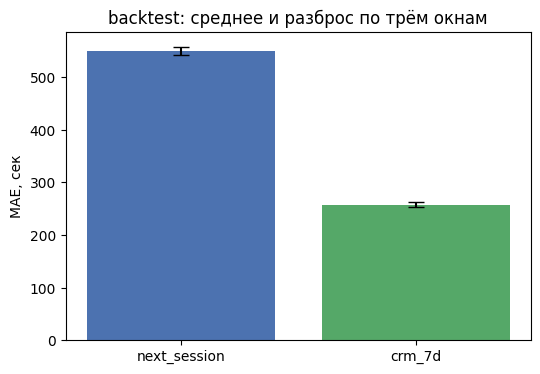

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([labels[t] for t in targets], [btres[t][0] for t in targets],
       yerr=[btres[t][1] for t in targets], capsize=6, color=["#4c72b0", "#55a868"])
ax.set_ylabel("MAE, сек")
ax.set_title("backtest: среднее и разброс по трём окнам")
plt.show()

## Калибровка прогноза
Средний факт против среднего прогноза по децилям прогноза, модель plain, test.

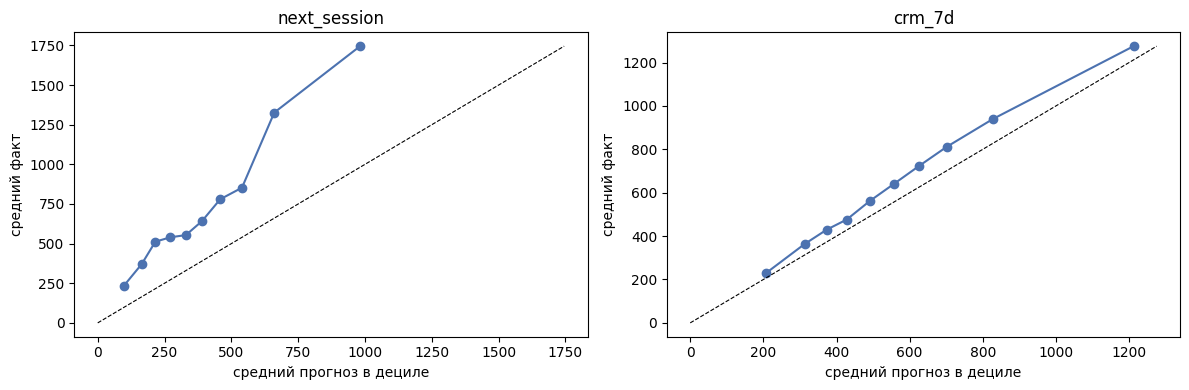

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, t in zip(axes, targets):
    yt, yp = preds[(t, "cat_plain_hastime")]
    q = pd.qcut(yp, 10, duplicates="drop")
    g = pd.DataFrame({"q": q, "yt": yt, "yp": yp}).groupby("q").mean()
    ax.plot(g["yp"], g["yt"], "o-", color="#4c72b0")
    lim = max(g["yp"].max(), g["yt"].max())
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlabel("средний прогноз в дециле")
    ax.set_ylabel("средний факт")
    ax.set_title(labels[t])
plt.tight_layout()
plt.show()

## Сегменты у стратегий таргета

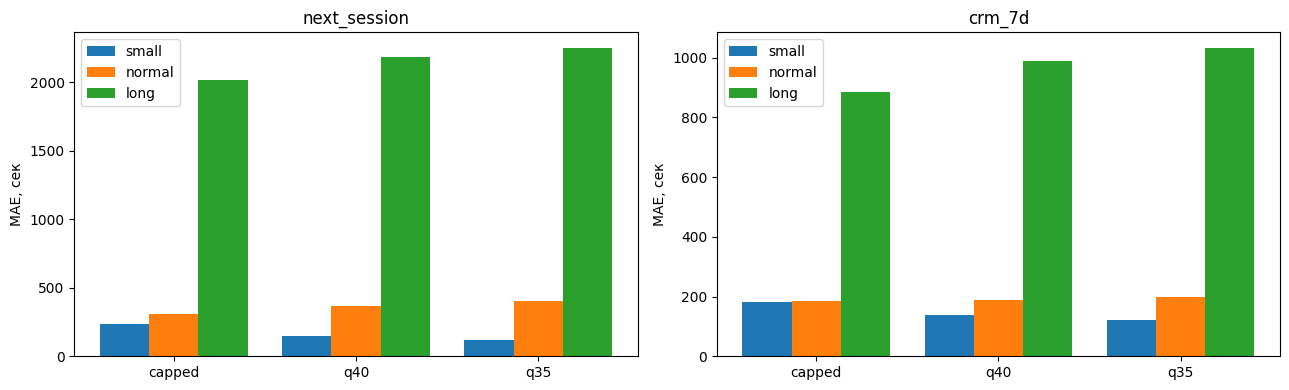

In [17]:
strat = ["cat_capped_target", "cat_quantile_40", "cat_quantile_35"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, t in zip(axes, targets):
    sub = res[res["target"] == t].set_index("model_name").loc[strat]
    x = np.arange(len(strat))
    w = 0.27
    ax.bar(x - w, sub["val_small_mae"], w, label="small")
    ax.bar(x, sub["val_normal_mae"], w, label="normal")
    ax.bar(x + w, sub["val_long_mae"], w, label="long")
    ax.set_xticks(x)
    ax.set_xticklabels(["capped", "q40", "q35"])
    ax.set_title(labels[t])
    ax.set_ylabel("MAE, сек")
    ax.legend()
plt.tight_layout()
plt.show()

In [18]:
pd.DataFrame(rows).to_csv("catres.csv", index=False)
out = {}
for key, val in preds.items():
    out[labels[key[0]] + "|" + key[1]] = np.vstack(val)
np.savez("catpreds.npz", **out)